# Swiggy Delivery Time Prediction

# 1. Business and Data Understanding

## Business Problem Stetement

Swiggy processes millions of food-delivery journeys across hundreds of cities every month. Accurate Estimated Time of Arrival (ETA) at order placement and during delivery is core to the customer experience — it affects conversion, cancellations, ratings, and retention. Today’s ETA accuracy suffers from many sources of uncertainty: highly variable traffic patterns, weather events, restaurant preparation variability, rider behaviour and skill, order batching/multiple deliveries, and city-specific operational constraints. Inaccurate ETAs cause:
>Reduced customer trust and lower repeat orders.

>Increased cancellations and refund costs.

> Higher support volume and operational interventions.

> Sub-optimal rider allocation and increased rider idle or overtime costs.


## Business Objective

Swiggy operates a large-scale food delivery platform where accurate prediction of delivery time is critical to customer satisfaction and operational efficiency. However, delivery durations are highly dynamic and influenced by multiple factors, including traffic conditions, weather disruptions, food  preparation times, rider behavior, geographical constraints, and city-specific operational patterns.

The existing uncertainty in ETA predictions can lead to reduced customer trust, increased order cancellations, higher customer support costs, inefficient rider utilization, and increased operational expenses. To address these challenges, the objective of this project is to develop a production-ready and scalable Machine Learning system capable of predicting per-order delivery time (in minutes) at the time of order placement and dynamically updating predictions as new information becomes available during the delivery lifecycle.

The proposed system will leverage both historical and real-time data sources, including order characteristics, rider information, restaurant attributes, geospatial features to provide business-grade confidence estimates to quantify prediction uncertainty, so the platform can
> Show reliable ETAs to customers

> Optimize rider allocation.


## Business constraints


| Constraint             | Description                                                             |
| ---------------------- | ----------------------------------------------------------------------- |
| Dynamic Traffic        | Traffic changes continuously throughout the day.                        |
| Weather Uncertainty    | Rain, storms, and extreme weather affect delivery times.                |
| Restaurant Variability | Preparation times differ across restaurants and cuisines.               |
| Rider Behaviour        | Delivery efficiency varies among riders.                                |
| Multi-Order Deliveries | Batch deliveries increase ETA complexity.                               |
| City Differences       | Infrastructure and traffic conditions vary significantly across cities. |
| Real-Time Requirements | Predictions should be generated within seconds.                         |

Datasource: [Access the CSV file here](https://drive.google.com/file/d/1vynZhL4DclYtx7tEEiqMHVWfcLLsEi_E/view?usp=sharing)

# 2. Data Preprocessing

In [1]:
!nvidia-smi


Wed Jul 22 02:58:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.49                 Driver Version: 596.49         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   53C    P8              3W /   75W |      11MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [84]:
#importing libraries
import numpy as np
import pandas as pd
!pip install matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
!pip install missingno
!pip install geopy
!pip install scikit-learn
!pip install jupyterlab_code_formatter black isort
from geopy.distance import geodesic
import missingno as msno
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
!pip install xgboost
from xgboost import XGBRegressor
!pip install lightgbm
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
!pip install optuna
import optuna
!pip install tensorflow
import tensorflow as tf
import pickle

In [85]:
#importing data from csv file
df=pd.read_csv(r"C:\Users\miraq\Downloads\swiggy_demographic (1).csv")
df.head(5)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,time_taken
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,24
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,33
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,26
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,21
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,30


In [86]:
df['weather'].unique()

array(['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan],
      dtype=object)

In [6]:
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus}")

GPUs available: []


In [7]:
# Overview of the imported data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  object 
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  object 
 8   weather               44977 non-null  object 
 9   traffic               44992 non-null  object 
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  object 
 12  type_of_vehicle       45502 non-null  object 
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  object 
 15  city_type          

Corrections : ---------------------------------NEED TO CROSS CHECK

Only found incorrect data type in dataset
1. Date and time columns should be date and time
2. The Order date and Order day and order month column give the same information. However using the date and monthly separately will help us encode and use theose features affectively.

## 1. Checking Missing values

In [8]:
missing_df = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": round(df.isnull().mean()*100,2)
})

missing_df.sort_values("Missing_%", ascending=False)

,Missing_Count,Missing_%
restaurant_latitude,3630,7.98
restaurant_longitude,3630,7.98
delivery_latitude,3630,7.98
delivery_longitude,3630,7.98
distance,3630,7.98
ratings,1908,4.19
age,1854,4.07
pickup_time_minutes,1640,3.60
order_time_hour,1640,3.60
city_type,1198,2.63


<Axes: >

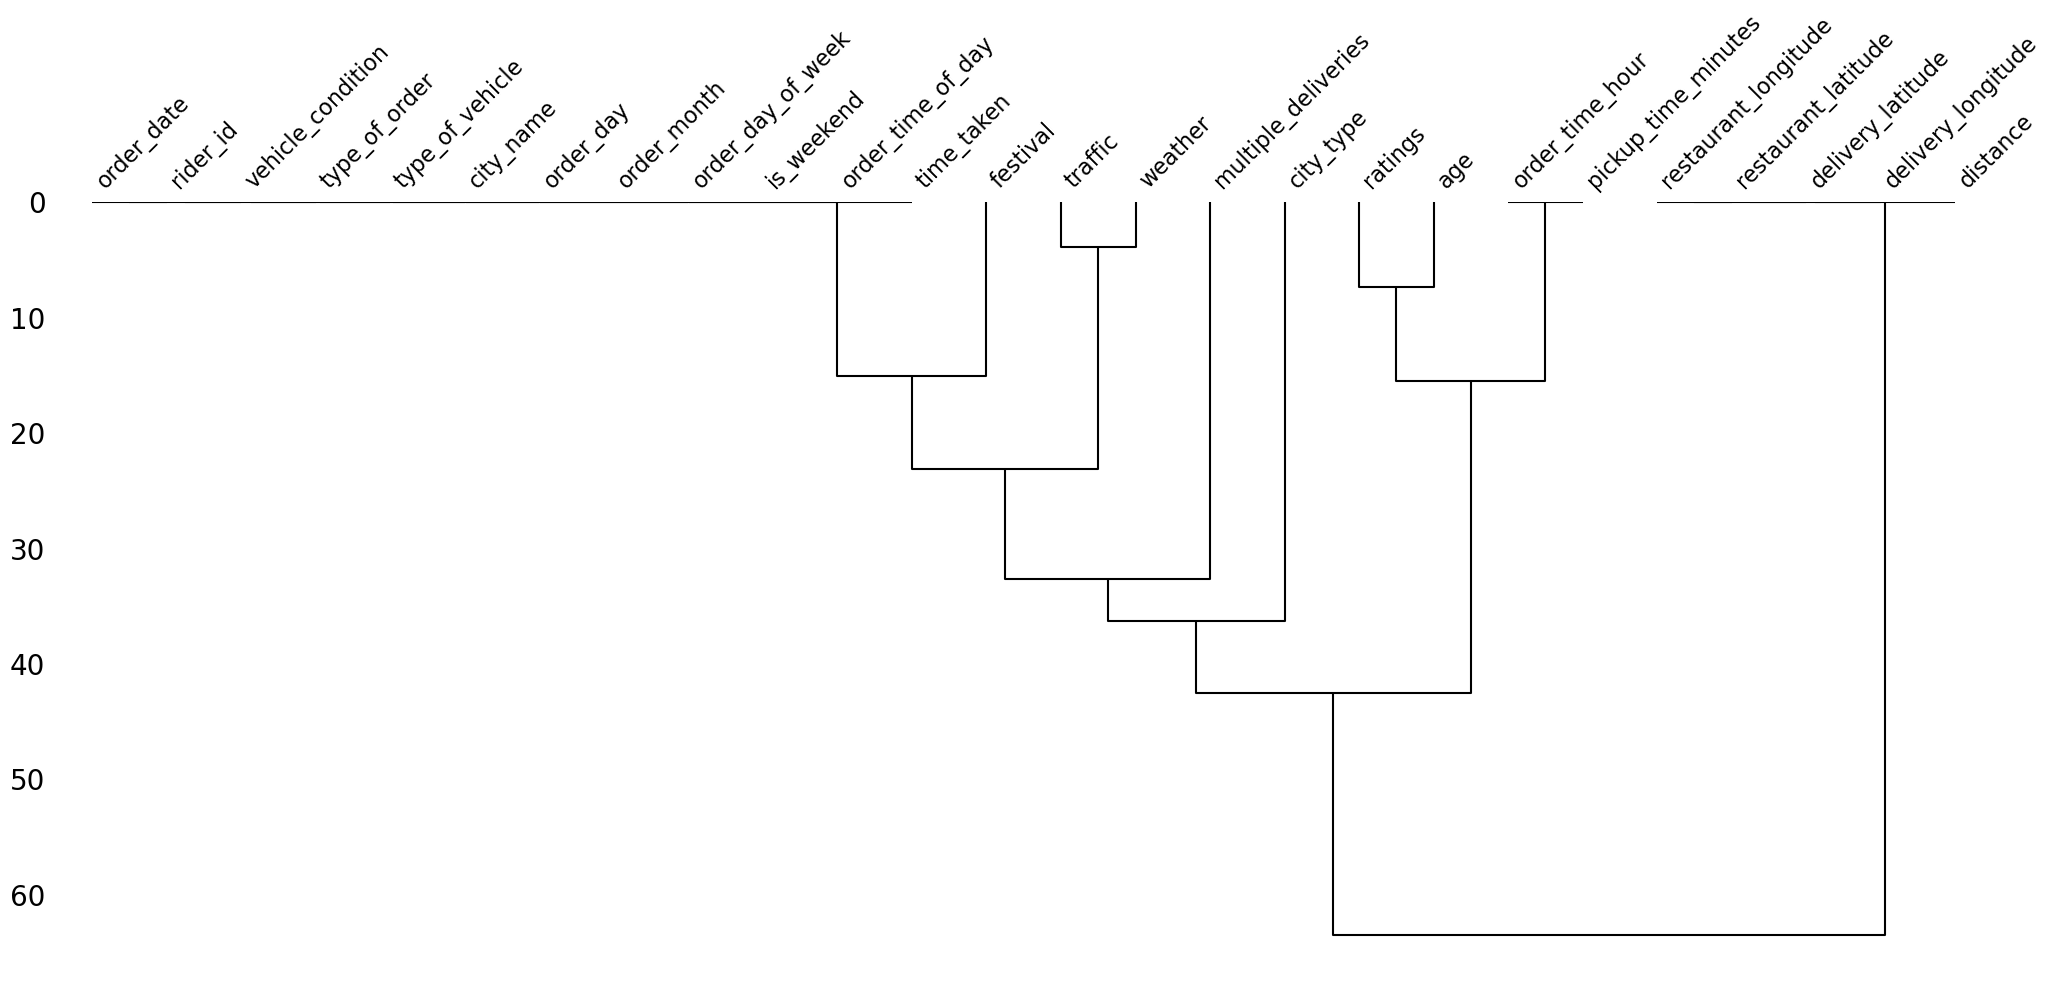

In [9]:
msno.dendrogram(df)

Missing values may occur because of:

1. GPS failures
2. Weather API downtime
3. Delayed system logging

## 2. Cheking for Duplicate rows

In [10]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found in the dataset

## 3. Data Type Validation/conversion

In [11]:
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)

In [12]:
np.dtype(df["order_date"])

dtype('<M8[ns]')

## Data Quality Assessment

Several data quality checks were performed:

#### Missing Values
Numerical missing values handled through imputation.
Categorical values imputed using most frequent category.

#### Duplicate Records

Duplicate records were checked and removed if necessary.

#### Data Type Validation

Data types were validated and corrected.

#### Outlier Detection

Numerical variables were analyzed for extreme values.

## 4. Univariate Analysis

In [13]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].skew().sort_values()

ratings                -1.793118
order_time_hour        -1.023568
age                    -0.014542
order_month            -0.012456
pickup_time_minutes     0.003900
vehicle_condition       0.060683
restaurant_latitude     0.106518
delivery_latitude       0.107230
order_day               0.299094
multiple_deliveries     0.325004
distance                0.325018
time_taken              0.485582
is_weekend              1.008587
delivery_longitude      1.193275
restaurant_longitude    1.194080
dtype: float64

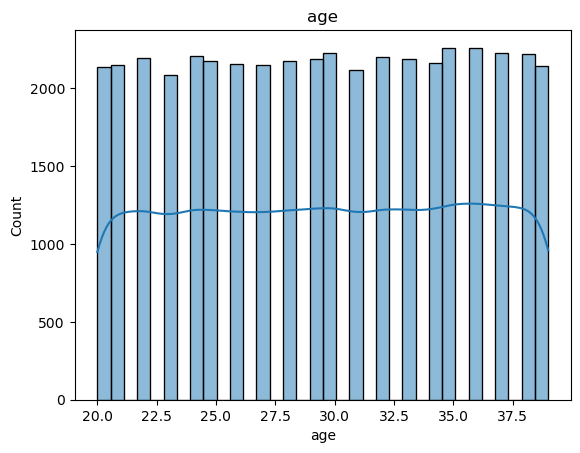

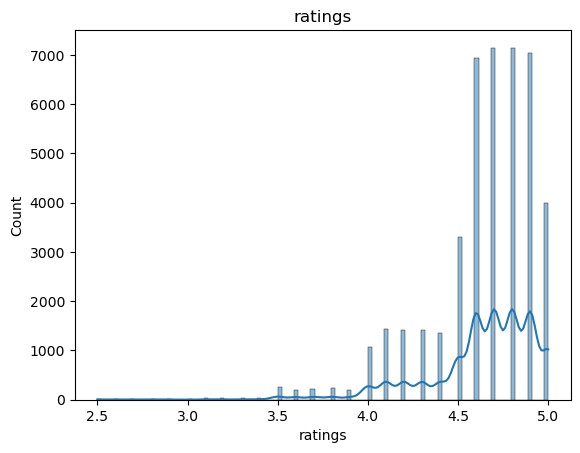

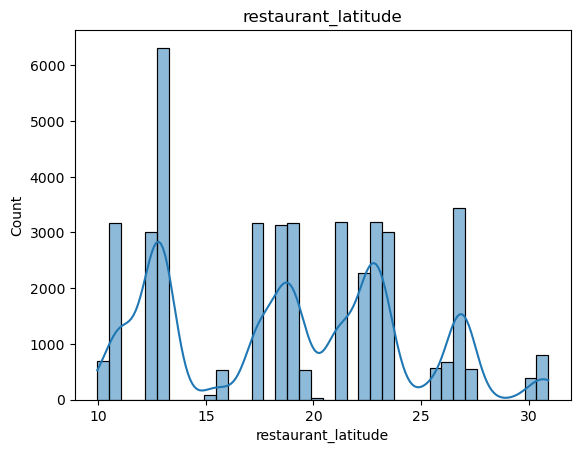

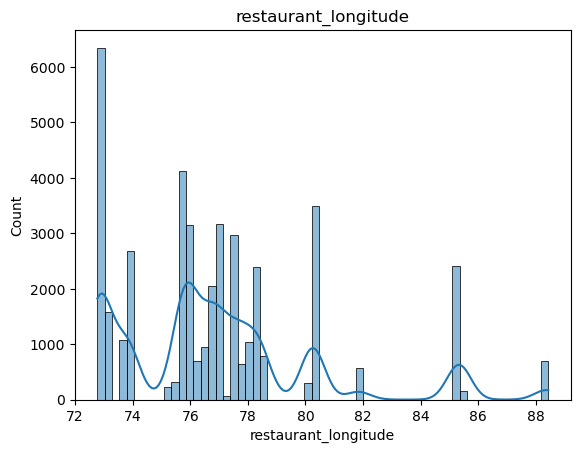

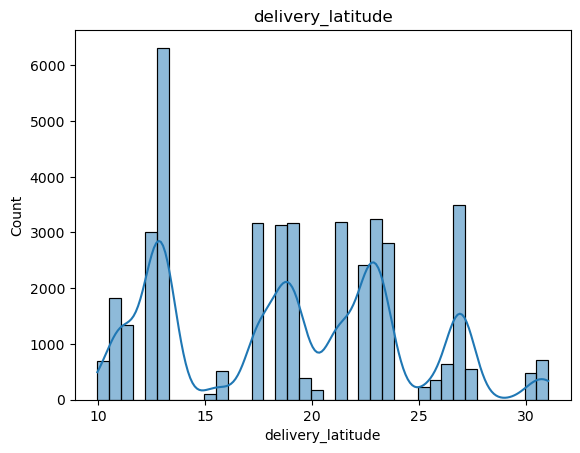

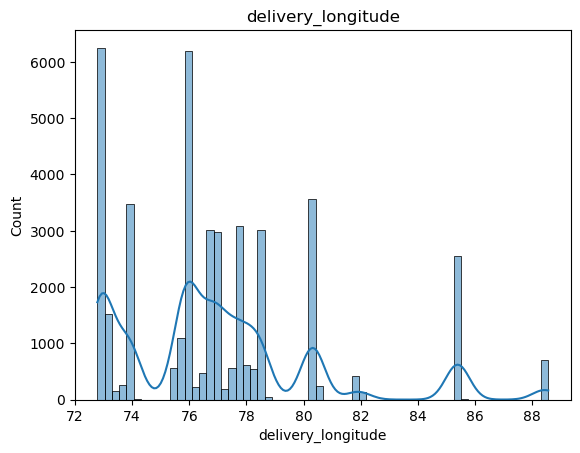

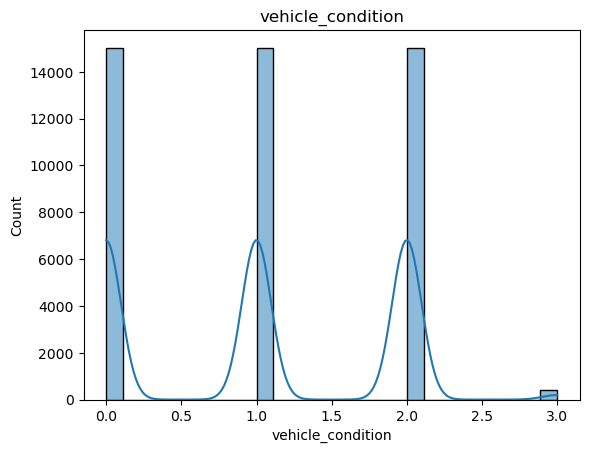

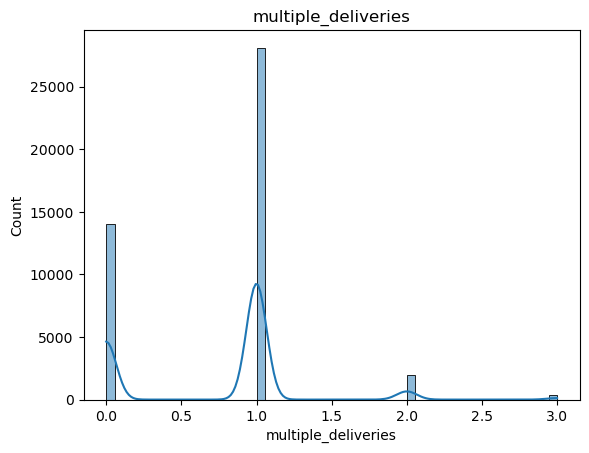

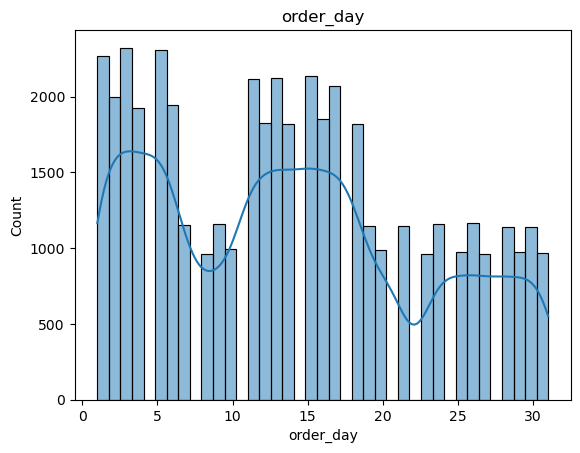

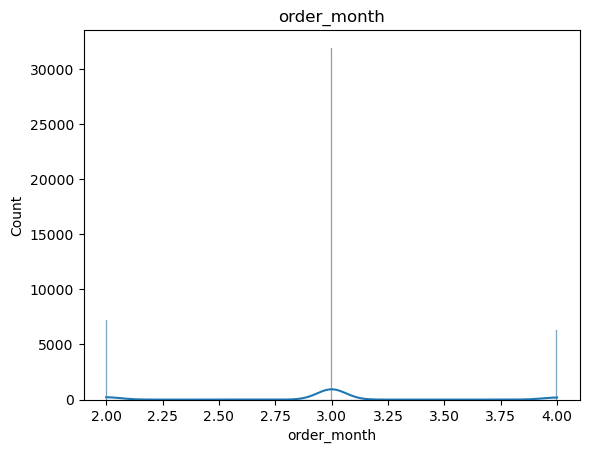

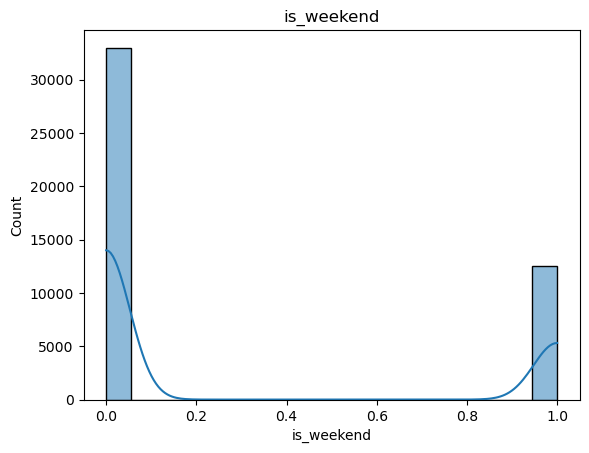

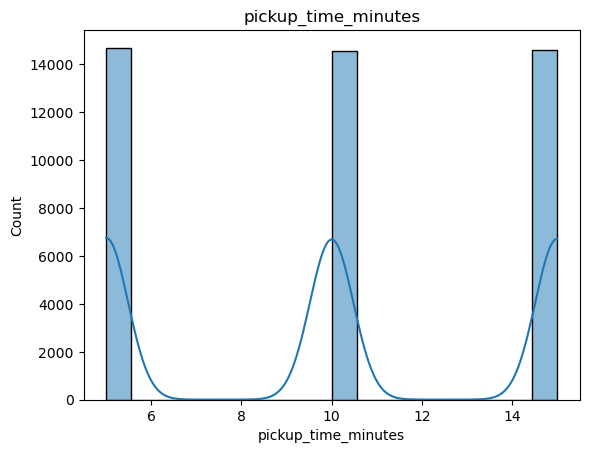

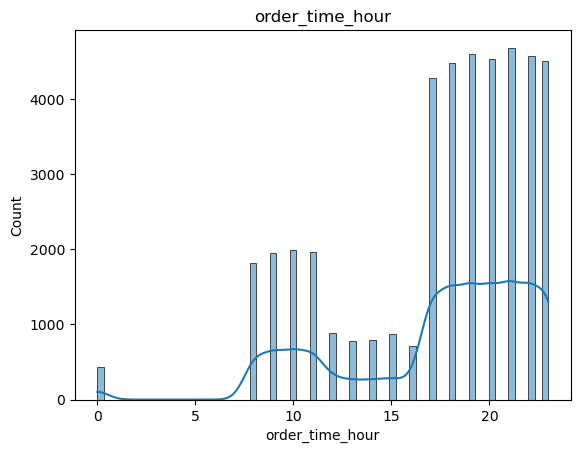

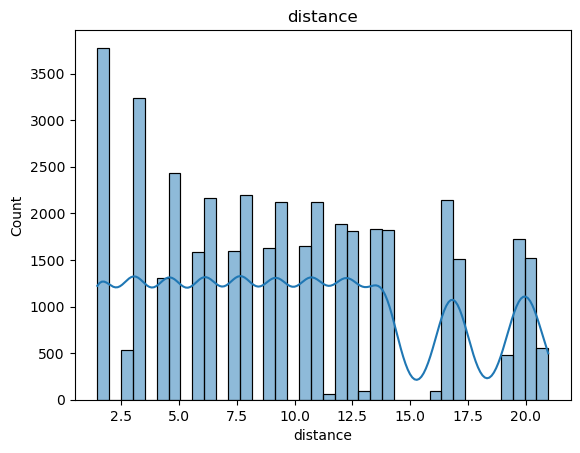

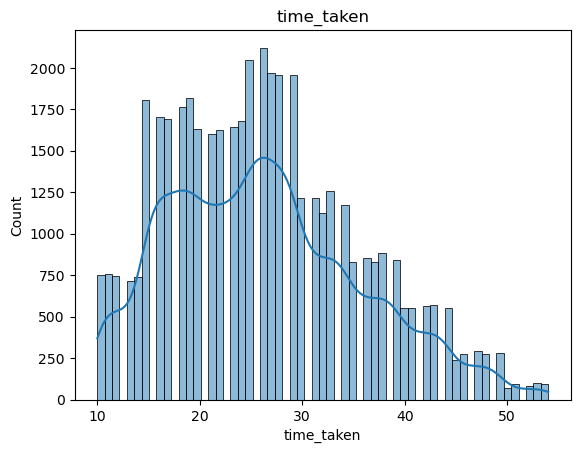

In [14]:
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

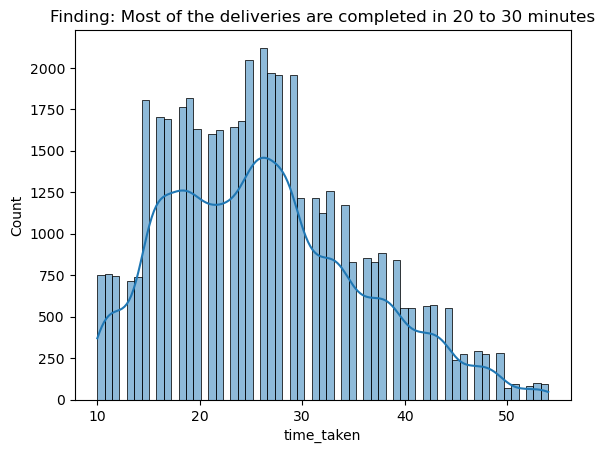

In [15]:
sns.histplot(df['time_taken'], kde=True)
plt. title ("Finding: Most of the deliveries are completed in 20 to 30 minutes")
plt.show()

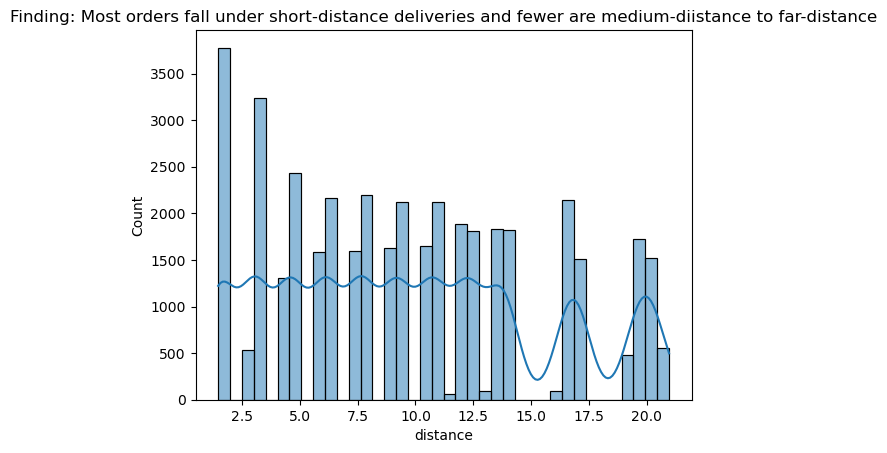

In [16]:
sns.histplot(df['distance'], kde=True)
plt. title ("Finding: Most orders fall under short-distance deliveries and fewer are medium-diistance to far-distance")
plt.show()

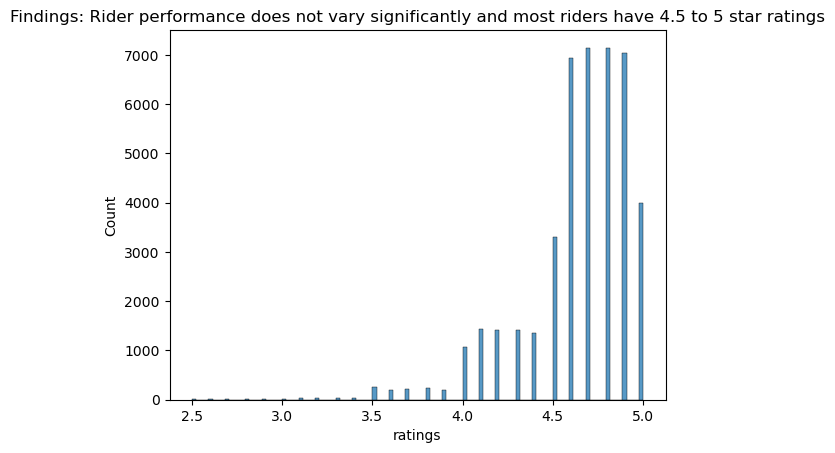

In [17]:
sns.histplot(df['ratings'])
plt. title ("Findings: Rider performance does not vary significantly and most riders have 4.5 to 5 star ratings")
plt.show()

## 5. Categorical Analysis

In [18]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['rider_id', 'weather', 'traffic', 'type_of_order', 'type_of_vehicle',
       'festival', 'city_type', 'city_name', 'order_day_of_week',
       'order_time_of_day'],
      dtype='object')

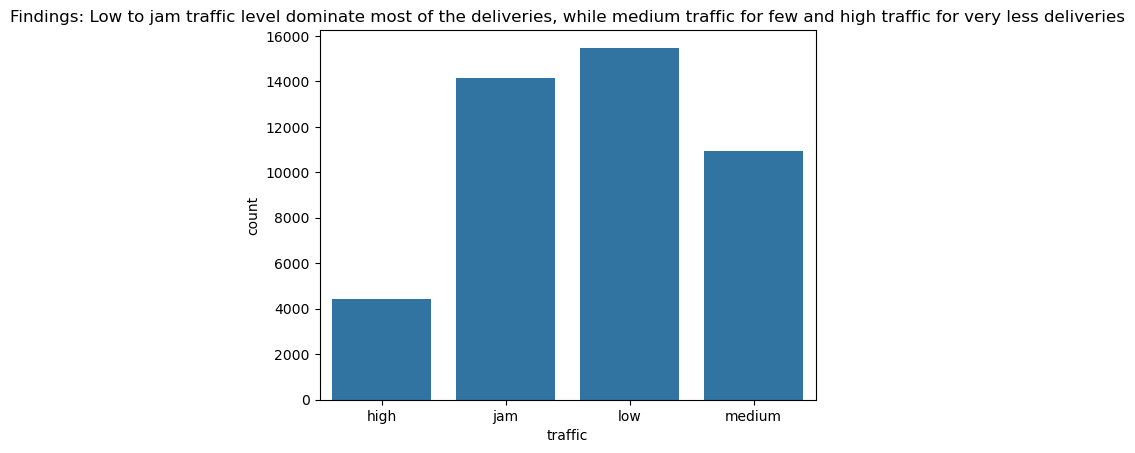

In [19]:
sns.countplot(data=df,x='traffic')
plt. title ("Findings: Low to jam traffic level dominate most of the deliveries, while medium traffic for few and high traffic for very less deliveries")
plt.show()

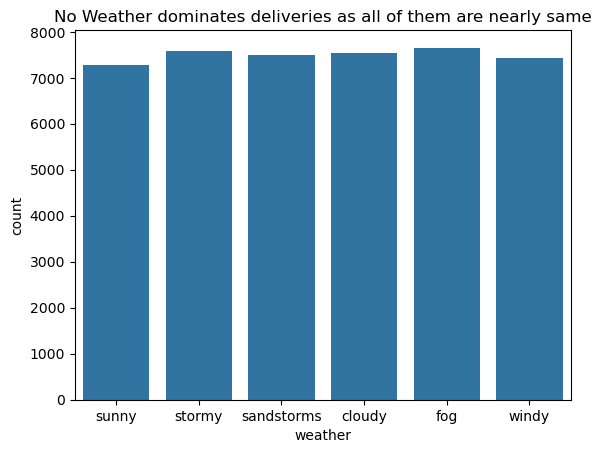

In [20]:
sns.countplot(data=df,x='weather')
plt. title ("No Weather dominates deliveries as all of them are nearly same")
plt.show()

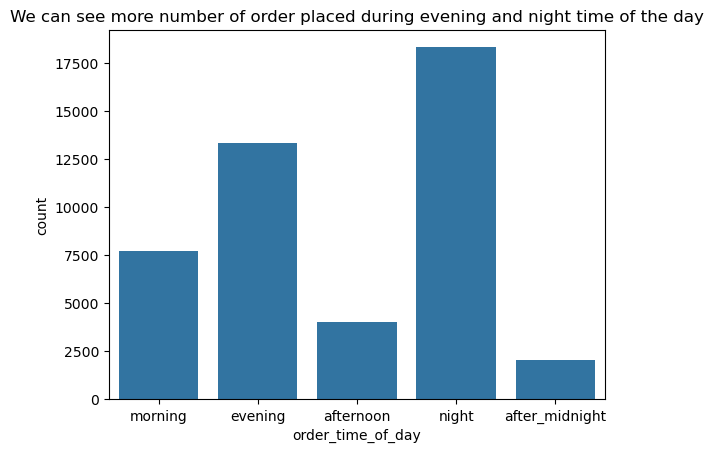

In [21]:
sns.countplot(data=df,x='order_time_of_day')
plt. title ("We can see more number of order placed during evening and night time of the day")
plt.show()

## 6. Target Variable Analysis

In [22]:
df['time_taken'].describe()

count    45502.000000
mean        26.297591
std          9.386419
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: time_taken, dtype: float64

## 7. Bivariate Analysis

## Here we will check which of the factors are mostly affecting the delivery time taken and if they have positive relation or a negative one.

<Axes: xlabel='distance', ylabel='time_taken'>

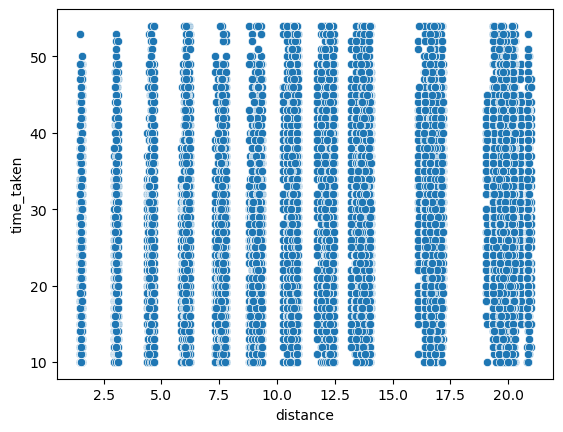

In [23]:
sns.scatterplot(
    x='distance',
    y='time_taken',
    data=df
)

<Axes: xlabel='traffic', ylabel='time_taken'>

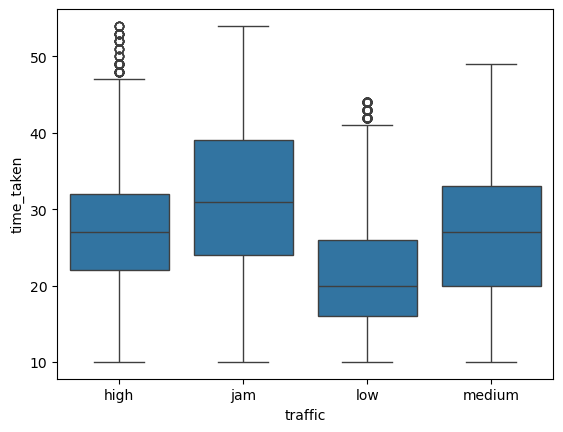

In [24]:
sns.boxplot(
    x='traffic',
    y='time_taken',
    data=df
)

<Axes: xlabel='multiple_deliveries', ylabel='time_taken'>

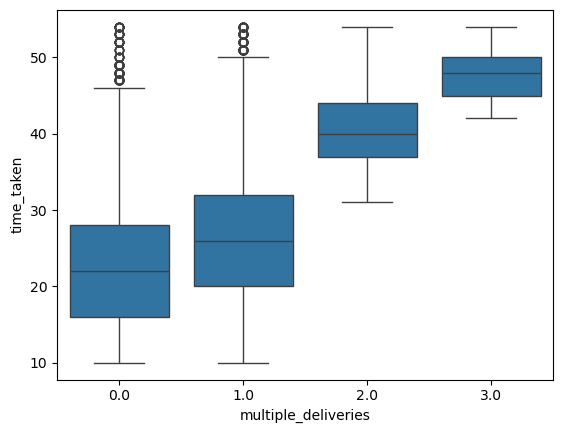

In [25]:
sns.boxplot(
    x='multiple_deliveries',
    y='time_taken',
    data=df
)

<Axes: xlabel='weather', ylabel='time_taken'>

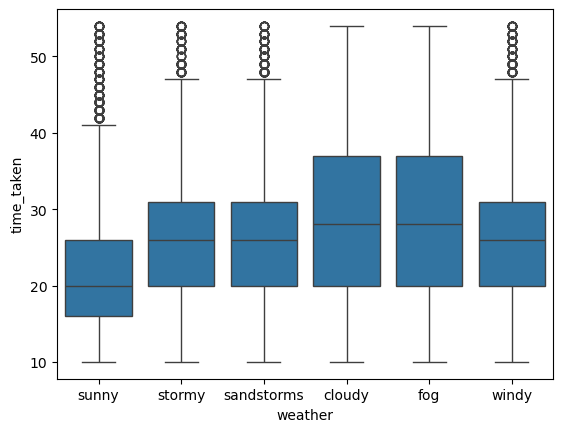

In [26]:
sns.boxplot(
    x='weather',
    y='time_taken',
    data=df
)

<Axes: xlabel='pickup_time_minutes', ylabel='time_taken'>

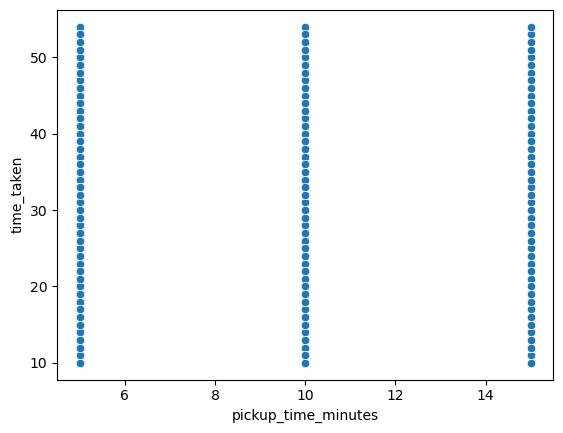

In [27]:
sns.scatterplot(
    x='pickup_time_minutes',
    y='time_taken',
    data=df
)

## 8. Correlation Analysis

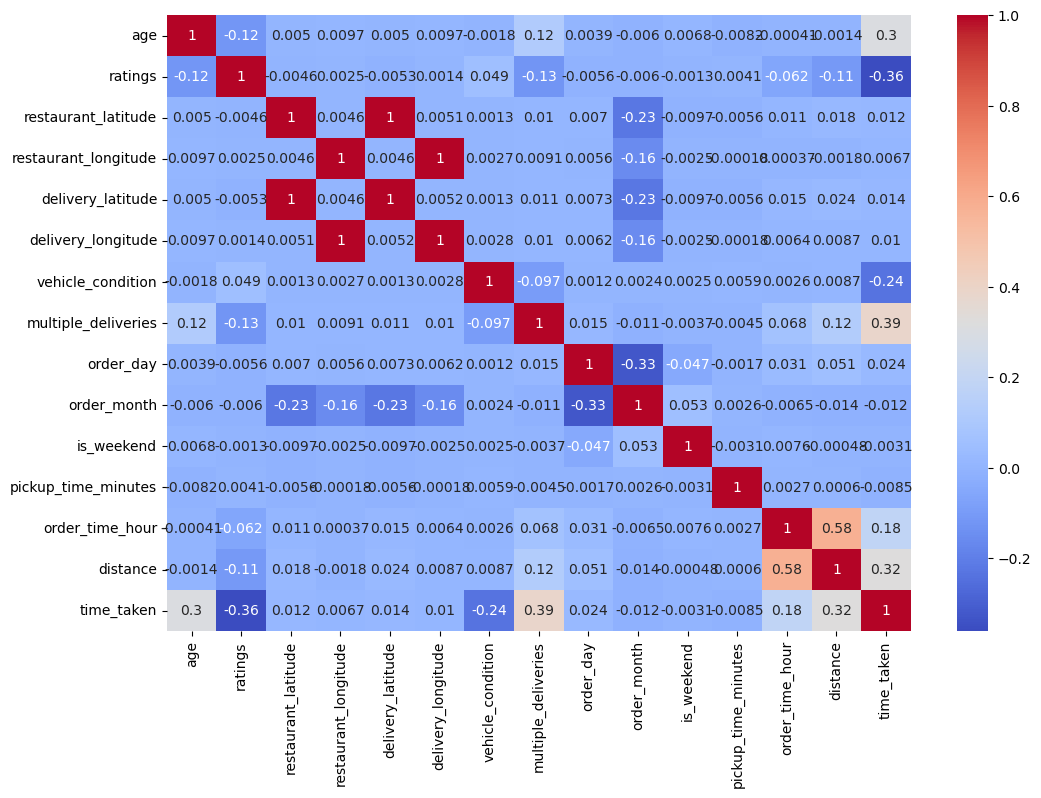

In [28]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

## 9. Outlier Detection

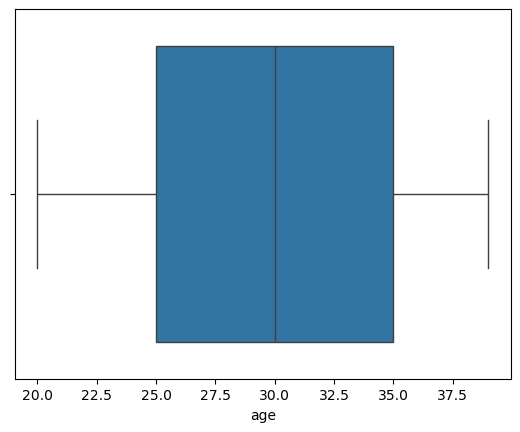

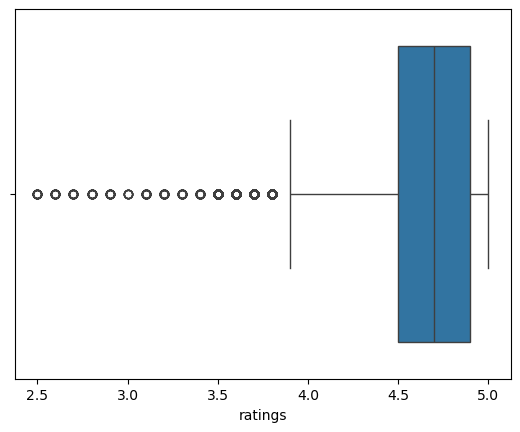

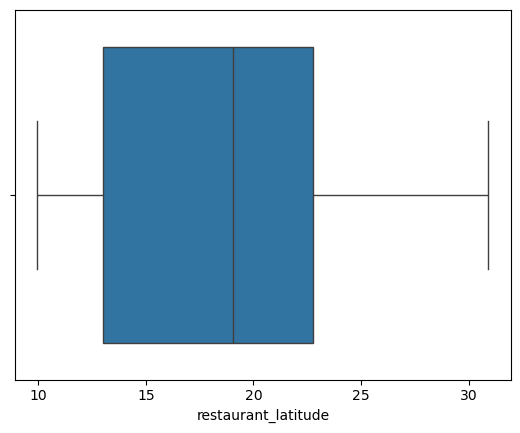

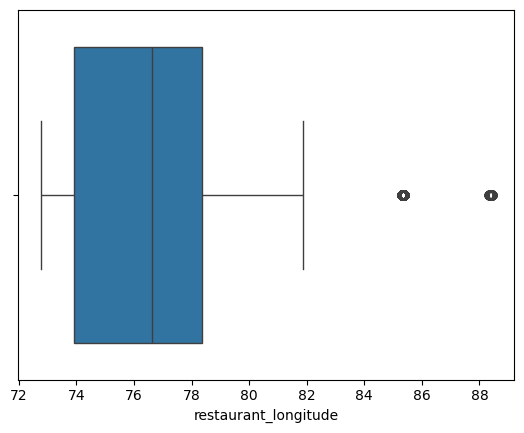

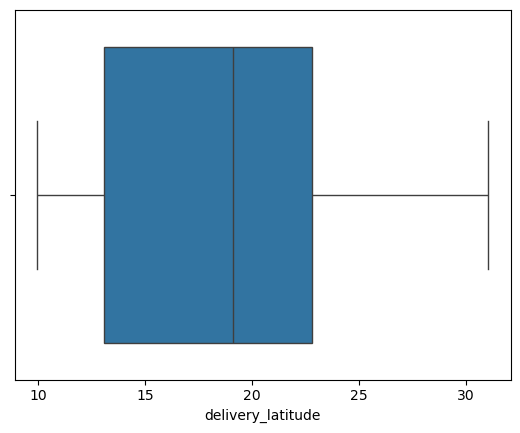

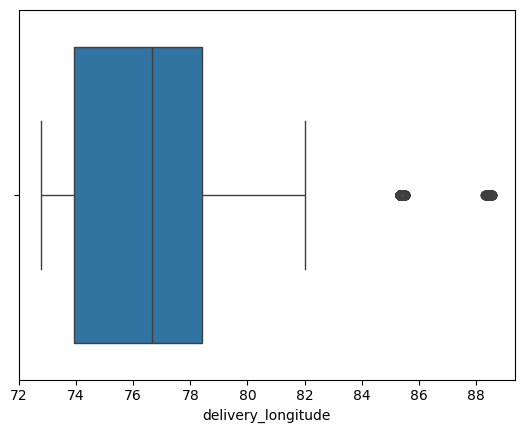

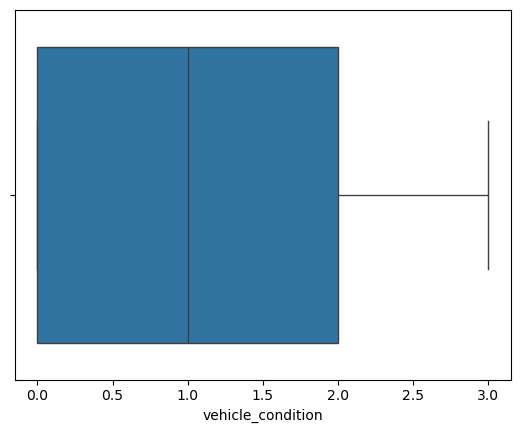

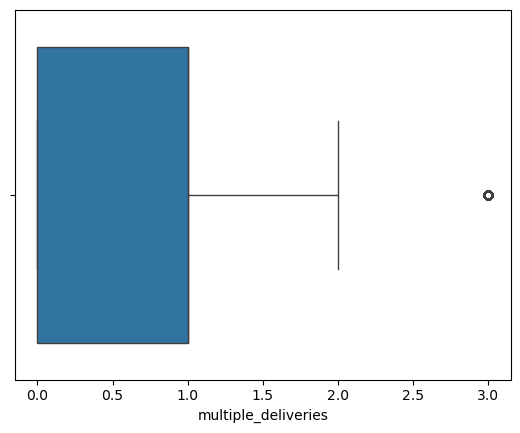

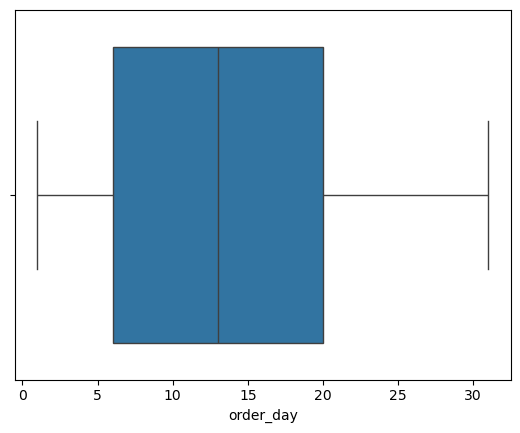

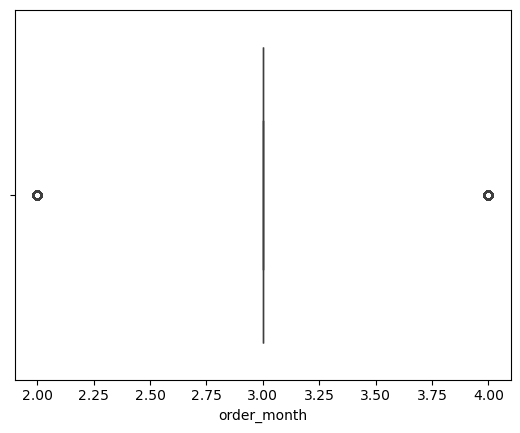

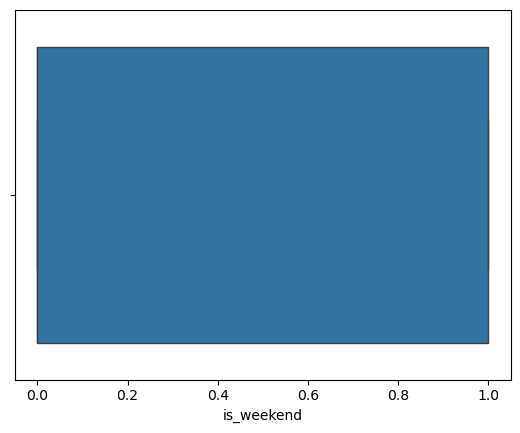

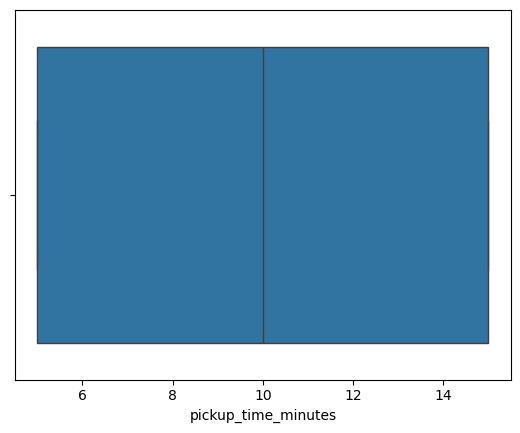

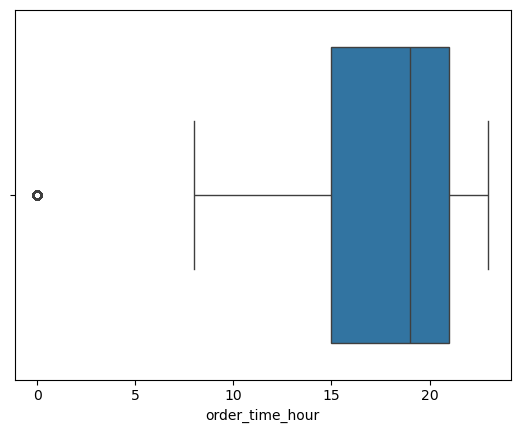

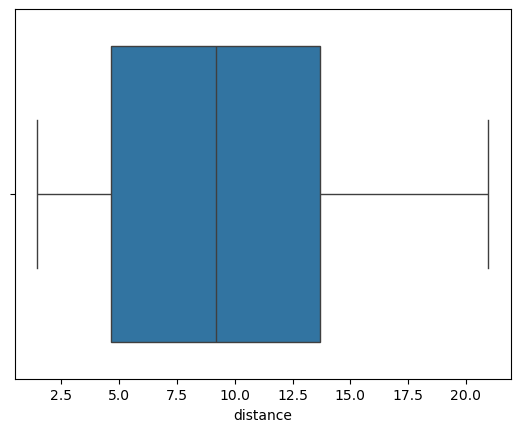

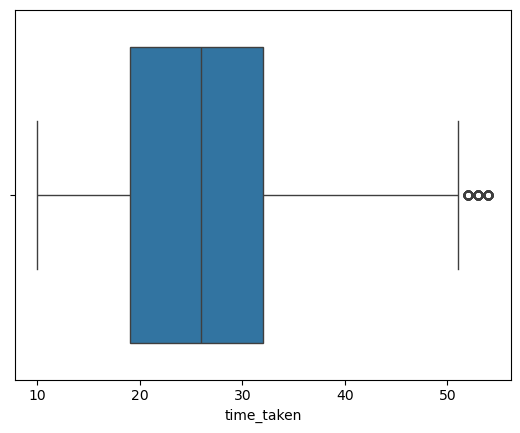

In [29]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

## Exploratory Data Analysis

#### Distribution Analysis
Delivery times
Distance
Pickup times
Rider ratings
Relationship Analysis

#### Studied relationships between:

Distance vs ETA
Traffic vs ETA
Multiple Deliveries vs ETA
Weather vs ETA
City vs ETA

#### Correlation Analysis
Correlation matrices were generated for numerical variables.

## 10. Feature Engineering

### Peak hour Feature

In [30]:
hourly_orders = (
    df.groupby('order_time_hour')
      .size()
      .reset_index(name='total_orders')
)

In [31]:
# define dynamic threshold for hourey orders
threshold = hourly_orders[
    'total_orders'
].quantile(0.75)

In [32]:
peak_hours = hourly_orders[
    hourly_orders['total_orders'] >= threshold
]['order_time_hour']

In [33]:
df['is_peak_hour'] = (
    df['order_time_hour']
      .isin(peak_hours)
      .astype(int)
)

In [34]:
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,time_taken,is_peak_hour
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,19,3,saturday,1,15.0,11.0,morning,3.025149,24,0
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,25,3,friday,0,5.0,19.0,evening,20.183530,33,1
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,19,3,saturday,1,15.0,8.0,morning,1.552758,26,0
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,5,4,tuesday,0,10.0,18.0,evening,7.790401,21,0
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,26,3,saturday,1,15.0,13.0,afternoon,6.210138,30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,24,3,thursday,0,10.0,11.0,morning,1.489846,32,0
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,16,2,wednesday,0,15.0,19.0,evening,NaN,36,1
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,11,3,friday,0,15.0,23.0,night,4.657195,16,1
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,7,3,monday,0,5.0,13.0,afternoon,6.232393,26,0


In [35]:
#Removing irrelavant features and separating numerical and categorical columns

df = df.drop(['order_date', "rider_id", 'restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude', 'is_weekend'], axis=1)
'''rider_ID column not required for model accuracy since city type and city name feature is already there and
order date is also not required since we already order day and order month features
removing gps features since we already have the distance feature'''

'rider_ID column not required for model accuracy since city type and city name feature is already there and\norder date is also not required since we already order day and order month features\nremoving gps features since we already have the distance feature'

In [36]:
df.isna().sum()

age                    1854
ratings                1908
weather                 525
traffic                 510
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     993
festival                228
city_type              1198
city_name                 0
order_day                 0
order_month               0
order_day_of_week         0
is_weekend                0
pickup_time_minutes    1640
order_time_hour        1640
order_time_of_day         0
distance               3630
time_taken                0
is_peak_hour              0
dtype: int64

## 11. Separating Numerical & Categorical Columns

In [37]:
num_cols = ["age", "ratings","vehicle_condition",
            "multiple_deliveries", "order_day",
            "order_month", "is_weekend",
            "pickup_time_minutes", "order_time_hour",
            "distance", "is_peak_hour"]

nom_cols = ["weather", "type_of_order",
            "type_of_vehicle", "city_name"]

ord_cols = ["traffic", "festival", "city_type", "order_day_of_week", "order_time_of_day"]

# Building the pipelines

#### Numerical transformer

In [38]:
Numerical_Transformer = Pipeline([("Scaling", StandardScaler ()),
                                  ("Numerical imputation", SimpleImputer(strategy="median")),
                                  ("Trandformation", PowerTransformer(method='yeo-johnson', standardize=True))]) # is feature scaling still required here?
Numerical_Transformer

,steps,"[('Scaling', ...), ('Numerical imputation', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True


#### Nominal transformer

In [39]:
Nominal_Transformer = Pipeline([("Nominal Imputation", SimpleImputer(strategy="most_frequent")),
                                ("One Hot Encoding", OneHotEncoder(drop="first", sparse_output=False))])
Nominal_Transformer

,steps,"[('Nominal Imputation', ...), ('One Hot Encoding', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


#### Ordinal Transformer

In [40]:
order_config = [["low","medium","high","jam"], ["no","yes"],
                ["semi-urban", "urban", "metropolitian"],
                ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"],
                ["morning", "afternoon", "evening", "night", "after_midnight"]]

In [41]:
Ordinal_Transformer = Pipeline([("Ordinal Imputation", SimpleImputer(strategy="most_frequent")),
                                ("Ordinal Encoding", OrdinalEncoder(categories=order_config))])
Ordinal_Transformer

,steps,"[('Ordinal Imputation', ...), ('Ordinal Encoding', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,"[['low', 'medium', ...], ['no', 'yes'], ...]"


#### Final Transformer

In [42]:
preprocessor = ColumnTransformer(transformers=[("Numerical transformer", Numerical_Transformer, num_cols),
                                      ("Nominal transformer", Nominal_Transformer, nom_cols),
                                      ("Ordinal Transformer", Ordinal_Transformer, ord_cols)])
preprocessor

,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### Evaluating Model

In [43]:
def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error (y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(
            y_test,
            y_pred))

    r2 = r2_score(y_test, y_pred)

    print (f"Mean Absolute Error is: {mae}, the less the better")
    print (f"Root Mean Squared Error is: {rmse}, the less the better")
    print (f"R2Score is: {r2}, The more the better")

### Evaluation Metrics

Primary Metric:

> MAE

Secondary Metrics:

> RMSE

> R²

## 12. Split data into train/test sets

In [44]:
X = df.drop (columns="time_taken", axis=1)
y = df["time_taken"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

# 13. Model Building and selection

##### KNN is Slow learner due to which the it has High Latency (Slow Predictions) and it is sensitive to noise as it treats all feature equally. Due to this KNN is not suitable for our problem.

## Models Evaluated

#### The following models were evaluated:

> Linear Regression

> Decision Tree

> Random Forest

> XGBoost

> LightGBM

> CatBoost

> SVR

### Baseline Model Linear Regression

In [46]:
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model',LinearRegression())])

lr_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
lr_pipeline.fit(
    X_train,
    y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
y_pred_lr = lr_pipeline.predict(X_test) # Trained on unseen data
y_train_lr = lr_pipeline.predict(X_train) # Trained on seen data

In [53]:
evaluate_model(y_train,y_train_lr)

Mean Absolute Error is: 4.971964414091219, the less the better
Root Mean Squared Error is: 6.260879091443628, the less the better
R2Score is: 0.5552458031634171, The more the better


In [54]:
evaluate_model(y_test,y_pred_lr)

Mean Absolute Error is: 4.994558955110838, the less the better
Root Mean Squared Error is: 6.291531917707754, the less the better
R2Score is: 0.5499895972276558, The more the better


### Model 1.1. Decision Tree

In [55]:
dt_pipeline = Pipeline(steps=[('preprocessor',preprocessor),
                              ('model',DecisionTreeRegressor(
                                  random_state=42))])

In [57]:
dt_pipeline.fit(
    X_train,
    y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
y_pred_dt = dt_pipeline.predict(X_test)
y_train_dt = dt_pipeline.predict(X_train)

In [64]:
evaluate_model(y_train,y_train_dt) #model performencae with seen data

Mean Absolute Error is: 0.0, the less the better
Root Mean Squared Error is: 0.0, the less the better
R2Score is: 1.0, The more the better


In [65]:
evaluate_model(y_test,y_pred_dt) #model performencae with unseen data

Mean Absolute Error is: 4.329853862212944, the less the better
Root Mean Squared Error is: 5.6856641896283575, the less the better
R2Score is: 0.6324874653164481, The more the better


### Model 1.2 Support vector Regressor

In [78]:
svr_pipeline = Pipeline(steps=[('preprocessor',preprocessor),
                               ('model', SVR())])

In [79]:
svr_pipeline.fit(X_train,
                 y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [80]:
y_pred_svr = svr_pipeline.predict(X_test)
y_train_svr = svr_pipeline.predict(X_train)

In [81]:
evaluate_model(y_train,y_train_svr) #model performencae with unseen data

Mean Absolute Error is: 4.159501069729658, the less the better
Root Mean Squared Error is: 5.347579423246734, the less the better
R2Score is: 0.6755379497097269, The more the better


In [82]:
evaluate_model(y_test,y_pred_svr) #model performencae with unseen data

Mean Absolute Error is: 4.277359981018815, the less the better
Root Mean Squared Error is: 5.4334877910752795, the less the better
R2Score is: 0.6643650823936844, The more the better


### Model 2 - Random Forest

In [83]:
rf_pipeline = Pipeline(steps=[('preprocessor',preprocessor),
                              ('model', RandomForestRegressor(
                                  n_estimators=200,
                                  random_state=42,
                                  n_jobs=-1))])

In [58]:
rf_pipeline.fit(
    X_train,
    y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
y_pred_rf = rf_pipeline.predict(X_test)
y_train_rf = rf_pipeline.predict(X_train)

In [ ]:
evaluate_model(y_train,y_train_rf) #Model performance with seen data

In [60]:
evaluate_model(y_test,y_pred_rf) #Model performance with unseen data

Mean Absolute Error is: 3.2940099989012195, the less the better
Root Mean Squared Error is: 4.16030947773779, the less the better
R2Score is: 0.8032290323196931, The more the better


In [62]:
cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

print(
    abs(cv_scores.mean())
)

3.291961677314582


### Model 3: XGBoost

In [63]:
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', XGBRegressor(random_state=42,
                                                      n_estimators=300,
                                                      learning_rate=0.05,
                                                      max_depth=8,
                                                      objective='reg:squarederror'))])

In [64]:
xgb_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
y_pred_xgb = xgb_pipeline.predict(X_test)
y_train_xgb = xgb_pipeline.predict(X_train)

In [ ]:
evaluate_model(y_train,y_train_xgb) #model performance with seen data

In [66]:
evaluate_model(y_test,y_pred_xgb) #model performance with unseen data

Mean Absolute Error is: 3.2351269721984863, the less the better
Root Mean Squared Error is: 4.059477635496432, the less the better
R2Score is: 0.8126515746116638, The more the better


### Model 4: LightGBM

In [67]:
 lgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('model', LGBMRegressor(
                                    random_state=42,
                                    n_estimators=300))])

In [68]:
lgb_pipeline.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002708 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 461
[LightGBM] [Info] Number of data points in the train set: 36401, number of used features: 48
[LightGBM] [Info] Start training from score 26.321942


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [69]:
y_pred_lgb = lgb_pipeline.predict(X_test)
y_train_lgb = lgb_pipeline.predict(X_train)

In [ ]:
evaluate_model(y_train,y_train_lgb) #model performance with seen data

In [70]:
evaluate_model(y_test,y_pred_lgb) #model performance with unseen data

Mean Absolute Error is: 3.2578524915707936, the less the better
Root Mean Squared Error is: 4.084431237763446, the less the better
R2Score is: 0.8103412328964407, The more the better


### Model 5: CatBoost

In [71]:
cat_pipeline = Pipeline(steps=[('preprocessor',preprocessor),
                               ('model',CatBoostRegressor(
                                   random_state=42,
                                   verbose=0))])

In [72]:
cat_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
y_pred_cat = cat_pipeline.predict(X_test)
y_train_cat = cat_pipeline.predict(X_train)

In [ ]:
evaluate_model(y_train,y_train_cat) #model performance with seen data

In [74]:
evaluate_model(y_test,y_pred_cat) #model performance with unseen data

Mean Absolute Error is: 3.260355988122668, the less the better
Root Mean Squared Error is: 4.093964903228294, the less the better
R2Score is: 0.8094548164681634, The more the better


# 14. Bias-Variance Tradeoff

### Bias and variance were analyzed using:

> Train MAE

> Test MAE

> Cross Validation MAE

##### This helped identify:

> Overfitting

> Underfitting

> Generalization ability

In [75]:
def bias_variance_analysis(model_pipeline,
                           X_train,
                           y_train,
                           X_test,
                           y_test):

    model_pipeline.fit(
        X_train,
        y_train)

    train_pred = model_pipeline.predict(
        X_train)

    test_pred = model_pipeline.predict(
        X_test)

    train_mae = mean_absolute_error(
        y_train,
        train_pred)

    test_mae = mean_absolute_error(
        y_test,
        test_pred)

    variance_gap = (test_mae - train_mae)

    return train_mae,\
           test_mae,\
           variance_gap

### Calculating Bias Variance Trade-off

#### Linear Regression

In [76]:
lr_train,\
lr_test,\
lr_gap = bias_variance_analysis(
    lr_pipeline,
    X_train,
    y_train,
    X_test,
    y_test)

#### Decision Tree

In [77]:
dt_train,\
dt_test,\
dt_gap = bias_variance_analysis(
    dt_pipeline,
    X_train,
    y_train,
    X_test,
    y_test)

#### Random Forest

In [78]:
rf_train,\
rf_test,\
rf_gap = bias_variance_analysis(
    rf_pipeline,
    X_train,
    y_train,
    X_test,
    y_test)

#### XGBoost

In [79]:
xgb_train,\
xgb_test,\
xgb_gap = bias_variance_analysis(
    xgb_pipeline,
    X_train,
    y_train,
    X_test,
    y_test)

#### LightGBM

In [80]:
lgb_train,\
lgb_test,\
lgb_gap = bias_variance_analysis(
    lgb_pipeline,
    X_train,
    y_train,
    X_test,
    y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 461
[LightGBM] [Info] Number of data points in the train set: 36401, number of used features: 48
[LightGBM] [Info] Start training from score 26.321942


#### CatBoost

In [81]:
cat_train,\
cat_test,\
cat_gap = bias_variance_analysis(
    cat_pipeline,
    X_train,
    y_train,
    X_test,
    y_test)

#### SVR

In [82]:
svr_train,\
svr_test,\
svr_gap = bias_variance_analysis(
    svr_pipeline,
    X_train,
    y_train,
    X_test,
    y_test)

### Creating Summary Table

In [83]:
bias_variance_df = pd.DataFrame({

    'Model':[

        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'CatBoost',
        'SVR'
    ],

    'Train MAE':[

        lr_train,
        dt_train,
        rf_train,
        xgb_train,
        lgb_train,
        cat_train,
        svr_train
    ],

    'Test MAE':[

        lr_test,
        dt_test,
        rf_test,
        xgb_test,
        lgb_test,
        cat_test,
        svr_test
    ],

    'Gap':[

        lr_gap,
        dt_gap,
        rf_gap,
        xgb_gap,
        lgb_gap,
        cat_gap,
        svr_gap
    ]
})

bias_variance_df.round(3)

,Model,Train MAE,Test MAE,Gap
0,Linear Regression,4.984,5.006,0.023
1,Decision Tree,0.000,4.323,4.323
2,Random Forest,1.208,3.294,2.086
3,XGBoost,2.528,3.235,0.707
4,LightGBM,2.936,3.258,0.322
5,CatBoost,2.946,3.260,0.314
6,SVR,4.168,4.280,0.113


### Visualize Bias-Variance

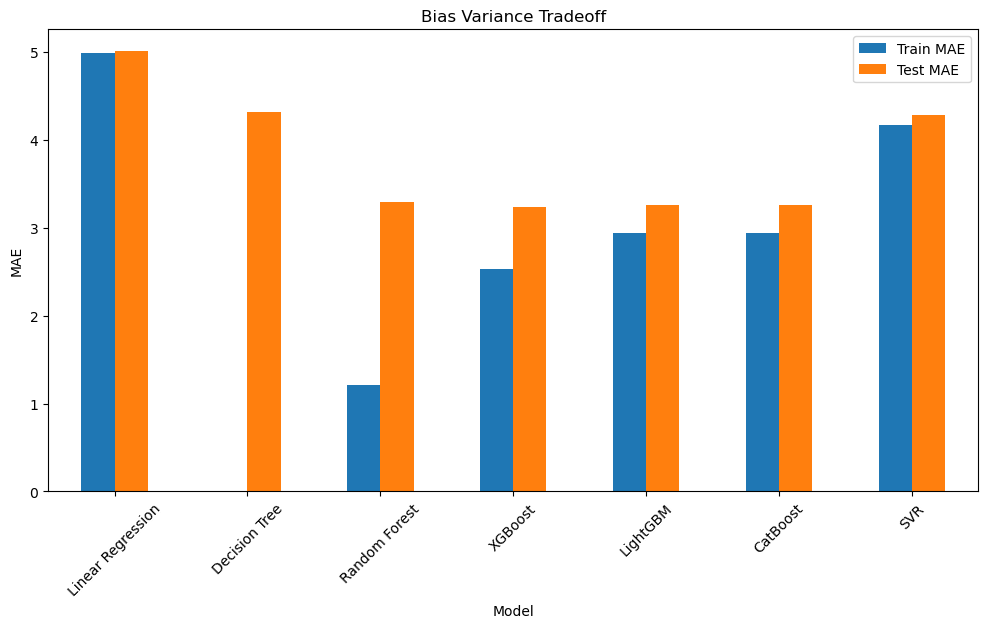

In [84]:
bias_variance_df.plot(x='Model',
                      y=['Train MAE', 'Test MAE'],
                      kind='bar',
                      figsize=(12,6))
plt.ylabel("MAE")

plt.title("Bias Variance Tradeoff")

plt.xticks(rotation=45)

plt.show()

### Interpretation

| Model    | Train | Test | Gap | Interpretation   |
| -------- | ----- | ---- | --- | ---------------- |
| Linear Regression       |  4.984   | 5.006  | 0.023 | High Bias        |
| Decision Tree       | 0.0   | 4.333  | 4.333 | Severe Overfit   |
| Random Forest       | 1.208   | 3.292  | 2.084 | Moderate Overfit |
| XGBoost      | 2.527   | 3.232  | 0.706 | Good             |
| LightGBM     | 2.936   | 3.258  | 0.322 | Good             |
| CatBoost | 2.942   | 3.255  | 0.313 | Best             |
| SVR      | 4.168   | 4.280  | 0.113 | High Bias        |


## Findings Based on Bias-Variance Tradeoff

Linear Regression is not suitable due to following:

>High bias.

>Train Error = High

>Test Error = High

>Model is too simple.

Decision Tree is not suitable due to following:

> High variance.

> Train Error ≈ 0

> Test Error = Very High

> Severe overfitting.

SVM is not suitable due to following:

> High bias.

> Train Error = High

> Test Error = High


The following models are good choice moving forward:
> Random Forest

> XGBoost

> LightGBM

>CatBoost

# 15. Cross-Validation

#### 5-Fold Cross Validation was performed to evaluate model stability.

In [85]:
def cross_validate_model(model,
                         X_train,
                         y_train):

    scores = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1)

    mae_scores = np.abs(scores)

    return {
        'Mean MAE':mae_scores.mean(),
        'Std MAE':mae_scores.std(),
        'All Scores':mae_scores
    }

#### Run for Every Model

In [86]:
cv_lr = cross_validate_model(
    lr_pipeline,
    X_train,
    y_train
)

cv_dt = cross_validate_model(
    dt_pipeline,
    X_train,
    y_train
)

cv_rf = cross_validate_model(
    rf_pipeline,
    X_train,
    y_train
)

cv_xgb = cross_validate_model(
    xgb_pipeline,
    X_train,
    y_train
)

cv_lgb = cross_validate_model(
    lgb_pipeline,
    X_train,
    y_train
)

cv_cat = cross_validate_model(
    cat_pipeline,
    X_train,
    y_train
)

cv_svr = cross_validate_model(
    svr_pipeline,
    X_train,
    y_train
)

#### Building cross validation table

In [87]:
cv_results = pd.DataFrame({
    'Model':['Linear Regression',
             'Decision Tree',
             'Random Forest',
             'XGBoost',
             'LightGBM',
             'CatBoost',
             'SVR'],

    'CV_MAE':[cv_lr['Mean MAE'],
              cv_dt['Mean MAE'],
              cv_rf['Mean MAE'],
              cv_xgb['Mean MAE'],
              cv_lgb['Mean MAE'],
              cv_cat['Mean MAE'],
              cv_svr['Mean MAE']],

    'Std':[cv_lr['Std MAE'],
           cv_dt['Std MAE'],
           cv_rf['Std MAE'],
           cv_xgb['Std MAE'],
           cv_lgb['Std MAE'],
           cv_cat['Std MAE'],
           cv_svr['Std MAE']]})

cv_results.round(3)


,Model,CV_MAE,Std
0,Linear Regression,5.001,0.041
1,Decision Tree,4.353,0.037
2,Random Forest,3.292,0.018
3,XGBoost,3.233,0.014
4,LightGBM,3.234,0.014
5,CatBoost,3.246,0.028
6,SVR,4.317,0.031


#### Merge with Bias-Variance Table

In [88]:
final_comparison = bias_variance_df.merge(
    cv_results,
    on='Model')

final_comparison

,Model,Train MAE,Test MAE,Gap,CV_MAE,Std
0,Linear Regression,4.983594,5.006159,0.022564,5.001125,0.040858
1,Decision Tree,0.000000,4.323261,4.323261,4.352545,0.037106
2,Random Forest,1.208080,3.294010,2.085930,3.291962,0.017739
3,XGBoost,2.527791,3.235127,0.707336,3.233465,0.013570
4,LightGBM,2.935805,3.257852,0.322047,3.234400,0.014092
5,CatBoost,2.946240,3.260356,0.314116,3.245904,0.028222
6,SVR,4.167698,4.280291,0.112594,4.317141,0.030870


### Final Model Selection Criteria

#### Primary:

✔ Lowest MAE

#### Secondary:

✔ Small Bias-Variance Gap

#### Third:

✔ Low CV Standard Deviation

#### Fourth:

✔ Fast inference time

# Model Selection Conclusion

#### Linear Regression is not suitable due to following:

> High bias.

> Model is too simple.

#### Decision Tree is not suitable due to following:

> Extreme Variance

> Train Error ≈ 0

> Test Error = Very High

> Severe overfitting.

#### SVM is not suitable due to following:

> High bias.

> Train Error = High

> Test Error = High

> Training becomes expensive.

Moving forward with following models for Hyperparameter Tuning:

> Random Forest

> XGBoost

> LightGBM

> CatBoost

### Models were evaluated using bias-variance analysis and 5-fold cross-validation. Models exhibiting high bias (Linear Regression) and high variance (Decision Tree) were eliminated. Ensemble boosting methods demonstrated superior generalization ability, lower cross-validation error, and more stable performance across folds. Consequently, CatBoost, LightGBM, and XGBoost were shortlisted for hyperparameter optimization.


### Cross-validation results indicated that ensemble methods significantly outperformed individual learners. XGBoost achieved the lowest prediction error, while LightGBM and CatBoost demonstrated the best bias-variance balance and generalization ability. Random Forest was retained as a benchmark ensemble model despite exhibiting mild overfitting.

# 16. Hyper Parameter Tuning

### Hyperparameter tuning was conducted for:

> Random Forest

> XGBoost

> LightGBM

> CatBoost

using:

> RandomizedSearchCV

> GridSearchCV

### Tuning Random Forest using RandomizedSearch

In [89]:
#creating list of parameters
rf_params = {'model__n_estimators':[200,300,500,700],
             'model__max_depth':[10,15,20,25,None],
             'model__min_samples_split':[2,5,10],
             'model__min_samples_leaf':[1,2,4],
             'model__max_features':['sqrt','log2',None]}

In [90]:
rf_search = RandomizedSearchCV(estimator=rf_pipeline,
                               param_distributions=rf_params,
                               n_iter=30,
                               cv=5,
                               scoring='neg_mean_absolute_error',
                               n_jobs=-1,
                               random_state=42,
                               verbose=2)

In [ ]:
rf_search.fit(X_train,
              y_train)

In [ ]:
best_rf = rf_search.best_estimator_

print(rf_search.best_params_)

print(abs(rf_search.best_score_))

## 16.2 XGBoost + Optuna

### 16.2.1 Objective Function

In [92]:
def objective_xgb(trial):

    params = {

        'n_estimators':
        trial.suggest_int('n_estimators',200,1000),
      'max_depth':trial.suggest_int('max_depth',3,12),
        'learning_rate':trial.suggest_float('learning_rate',0.01,0.3,log=True),
        'subsample':trial.suggest_float('subsample',0.6,1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree',0.6,1.0),
        'min_child_weight':trial.suggest_int('min_child_weight',1,10),
        'gamma':trial.suggest_float('gamma',0,5),
        'random_state':42,
        'objective':'reg:squarederror'}

    model = Pipeline(steps=[('preprocessor',preprocessor),
                            ('model',XGBRegressor(**params))])

    score = cross_val_score(model,
                            X_train,
                            y_train,
                            cv=5,
                            scoring='neg_mean_absolute_error',
                            n_jobs=-1)

    return abs(score.mean())

In [93]:
study_xgb = optuna.create_study(direction='minimize')

study_xgb.optimize(objective_xgb,
                   n_trials=50)

[I 2026-07-22 03:32:33,010] A new study created in memory with name: no-name-a82c4e96-9058-461c-a673-969ea53bbdb5
[I 2026-07-22 03:32:48,124] Trial 0 finished with value: 3.2373183250427244 and parameters: {'n_estimators': 760, 'max_depth': 9, 'learning_rate': 0.017058730063857414, 'subsample': 0.6647116083796522, 'colsample_bytree': 0.6940782752432396, 'min_child_weight': 9, 'gamma': 3.4135564081166976}. Best is trial 0 with value: 3.2373183250427244.
[I 2026-07-22 03:33:03,210] Trial 1 finished with value: 3.2323171615600588 and parameters: {'n_estimators': 820, 'max_depth': 8, 'learning_rate': 0.015926161534931198, 'subsample': 0.9089160035322323, 'colsample_bytree': 0.6717773198989876, 'min_child_weight': 8, 'gamma': 1.531164927251698}. Best is trial 1 with value: 3.2323171615600588.
[I 2026-07-22 03:33:15,745] Trial 2 finished with value: 3.295723628997803 and parameters: {'n_estimators': 836, 'max_depth': 7, 'learning_rate': 0.07449655417587756, 'subsample': 0.9706124092848731, '

In [94]:
study_xgb.best_params

{'n_estimators': 399,
 'max_depth': 10,
 'learning_rate': 0.02122513148469739,
 'subsample': 0.9290481026780281,
 'colsample_bytree': 0.8911257668778712,
 'min_child_weight': 7,
 'gamma': 0.8455610922190242}

### Training XGBoost with best parameters

In [95]:
best_xgb = Pipeline(steps=[('preprocessor',preprocessor),
                           ('model',XGBRegressor(**study_xgb.best_params,random_state=42,
                                                 objective='reg:squarederror'))])

best_xgb.fit(X,y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 16.2.2 LightGBM + Optuna

### Objective

In [96]:
def objective_lgb(trial):

    params = {'n_estimators':trial.suggest_int('n_estimators',200,1000),
              'max_depth':trial.suggest_int('max_depth',3,15),
              'learning_rate':trial.suggest_float('learning_rate',0.01,0.3,log=True),
              'num_leaves':trial.suggest_int('num_leaves',20,200),
              'subsample':trial.suggest_float('subsample',0.6,1.0),
              'colsample_bytree':trial.suggest_float('colsample_bytree',0.6,1.0),
              'random_state':42}

    model = Pipeline(steps=[('preprocessor',preprocessor),
     ('model',LGBMRegressor(**params))])

    score = cross_val_score(model,
                            X_train,
                            y_train,
                            cv=5,
                            scoring='neg_mean_absolute_error',
                            n_jobs=-1)

    return abs(score.mean())

In [97]:
study_lgb = optuna.create_study(
    direction='minimize')

study_lgb.optimize(objective_lgb,
                   n_trials=50)

[I 2026-07-22 03:39:55,635] A new study created in memory with name: no-name-5daa2265-d936-4ed7-8e73-532aa4c764b9
[I 2026-07-22 03:40:12,084] Trial 0 finished with value: 3.2460429575136063 and parameters: {'n_estimators': 937, 'max_depth': 8, 'learning_rate': 0.05397645236354322, 'num_leaves': 38, 'subsample': 0.995462881574344, 'colsample_bytree': 0.8470943354271492}. Best is trial 0 with value: 3.2460429575136063.
[I 2026-07-22 03:40:39,160] Trial 1 finished with value: 3.3664232022664664 and parameters: {'n_estimators': 925, 'max_depth': 7, 'learning_rate': 0.14026128053615933, 'num_leaves': 168, 'subsample': 0.7582821400368567, 'colsample_bytree': 0.6159804245101319}. Best is trial 0 with value: 3.2460429575136063.
[I 2026-07-22 03:40:44,073] Trial 2 finished with value: 3.319024438865526 and parameters: {'n_estimators': 252, 'max_depth': 5, 'learning_rate': 0.12123741795524605, 'num_leaves': 180, 'subsample': 0.9956157625180435, 'colsample_bytree': 0.9702041290803984}. Best is tr

In [113]:
best_lgb = Pipeline(steps=[('preprocessor',preprocessor),
 ('model',LGBMRegressor(**study_lgb.best_params,random_state=42))])

best_lgb.fit(X,y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004647 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 461
[LightGBM] [Info] Number of data points in the train set: 45502, number of used features: 48
[LightGBM] [Info] Start training from score 26.297591


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## CatBoost + Optuna

### Objective

In [99]:
def objective_cat(trial):

    params = {'iterations':trial.suggest_int('iterations',300,1000),
              'depth':trial.suggest_int('depth',4,12),
              'learning_rate':trial.suggest_float('learning_rate',0.01,0.3,log=True),
              'l2_leaf_reg':trial.suggest_float('l2_leaf_reg',1,20),
              'bagging_temperature':trial.suggest_float('bagging_temperature',0,5),
              'random_state':42,'verbose':0}

    model = Pipeline(steps=[('preprocessor',preprocessor),
     ('model',CatBoostRegressor(**params))])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1)

    return abs(score.mean())

In [100]:
study_cat = optuna.create_study(direction='minimize')

study_cat.optimize(objective_cat, n_trials=50)

[I 2026-07-22 04:00:34,410] A new study created in memory with name: no-name-136dbe2f-a003-46c1-b5b6-7bd36ccdd3a4
[I 2026-07-22 04:00:58,356] Trial 0 finished with value: 3.221776509448316 and parameters: {'iterations': 812, 'depth': 8, 'learning_rate': 0.03899259843780659, 'l2_leaf_reg': 3.30256470402392, 'bagging_temperature': 2.419900113364975}. Best is trial 0 with value: 3.221776509448316.
[I 2026-07-22 04:01:52,558] Trial 1 finished with value: 3.317162266696454 and parameters: {'iterations': 361, 'depth': 12, 'learning_rate': 0.017261628405744227, 'l2_leaf_reg': 18.17511096839723, 'bagging_temperature': 3.4341668624220323}. Best is trial 0 with value: 3.221776509448316.
[I 2026-07-22 04:02:11,532] Trial 2 finished with value: 3.2515138770884007 and parameters: {'iterations': 816, 'depth': 7, 'learning_rate': 0.03402291372299272, 'l2_leaf_reg': 3.1725877747163223, 'bagging_temperature': 4.718977133436175}. Best is trial 0 with value: 3.221776509448316.
[I 2026-07-22 04:02:41,168]

In [114]:
best_cat = Pipeline(steps=[('preprocessor',preprocessor),
 ('model',CatBoostRegressor(**study_cat.best_params,
                            random_state=42,
                            verbose=0))])

best_cat.fit(X,y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical transformer', ...), ('Nominal transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Final Comparison After Tuning

In [102]:
models = {'XGB':best_xgb,
          'LGBM':best_lgb,
          'CAT':best_cat}

In [103]:
final_results = []

for name, model in models.items():
  pred = model.predict(X_test)

  mae = mean_absolute_error(y_test,pred)

  rmse = np.sqrt(mean_squared_error(y_test,pred))

  r2 = r2_score(y_test,pred)

  final_results.append([name,
                        mae,
                        rmse,
                        r2])

In [104]:
final_results_df = pd.DataFrame(final_results,
             columns=['Model','MAE','RMSE','R2']).sort_values('MAE')

final_results_df.round(3)

,Model,MAE,RMSE,R2
1,LGBM,3.182,3.993,0.819
2,CAT,3.235,4.067,0.812
0,XGB,3.530,4.799,0.738


#### After performing hyperparameter tuning and evaluating the top-performing ensemble models using MAE, RMSE, and R² metrics, LightGBM (LGBM) was selected as the final production model for the Swiggy ETA Prediction System.

| Model    | MAE       | RMSE      | R²        |
| -------- | --------- | --------- | --------- |
| **LGBM** | **3.182** | **3.993** | **0.819** |
| CatBoost | 3.235     | 4.067     | 0.812     |
| XGBoost  | 3.530     | 4.799     | 0.738     |

Conclusion:
LightGBM achieved the lowest Mean Absolute Error (3.182 minutes), indicating the highest prediction accuracy among all tuned models.
It also produced the lowest RMSE (3.993), demonstrating better handling of larger prediction errors.
With an R² score of 0.819, the model explains approximately 81.9% of the variance in delivery times, indicating strong predictive capability.
Additionally, LightGBM provides faster training and inference times, making it suitable for real-time ETA prediction systems where quick responses are essential.

## Feature Importance

In [115]:
final_model = best_lgb

In [116]:
feature_names = (final_model.named_steps['preprocessor']
                 .get_feature_names_out())

In [117]:
importance = (final_model.named_steps['model']
              .feature_importances_)

In [118]:
feature_df = pd.DataFrame({'Feature':feature_names,'Importance':importance})

feature_df = feature_df.sort_values('Importance',ascending=False)

In [119]:
feature_df

,Feature,Importance
9,Numerical transformer__distance,13664
0,Numerical transformer__age,7691
4,Numerical transformer__order_day,6140
1,Numerical transformer__ratings,5401
2,Numerical transformer__vehicle_condition,4187
8,Numerical transformer__order_time_hour,3819
43,Ordinal Transformer__traffic,3688
3,Numerical transformer__multiple_deliveries,2961
14,Nominal transformer__weather_sunny,2910
46,Ordinal Transformer__order_day_of_week,2749


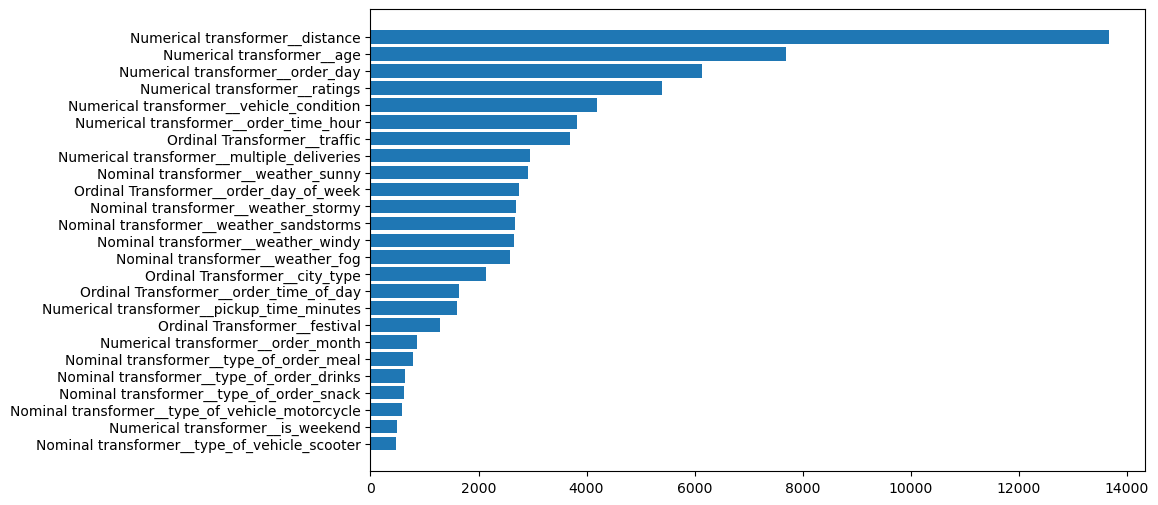

In [120]:
top_features = (
    feature_df
    .head(25)
)

plt.figure(
    figsize=(10,6)
)

plt.barh(

    top_features['Feature'],

    top_features['Importance']
)

plt.gca().invert_yaxis()

plt.show()

### Conclusion

Feature importance analysis revealed that the most influential features were:

> Distance

> Pickup Preparation Time

> Traffic Conditions

> Multiple Deliveries

> Weather Conditions

> City Information

## Saving/Pickling the file

In [121]:
with open (r"C:\Users\miraq\Downloads\Pipeline pickle\PL_Swiggy_delivery_time_prediction.pkl", "wb") as f:
    pickle.dump(final_model, f)

In [123]:
X.columns.tolist()

['age',
 'ratings',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'city_name',
 'order_day',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'pickup_time_minutes',
 'order_time_hour',
 'order_time_of_day',
 'distance',
 'is_peak_hour']

# Deployment

####  A Streamlit application was developed to provide real-time ETA predictions.

Deployment Features

Interactive UI

Dark theme dashboard

Auto-generated temporal features

Real-time prediction engine

Model performance indicators

# Business Impact

#### Implementation of this model can:

Improve Customer Satisfaction

By providing more accurate ETAs.

Reduce Order Cancellations

Customers are less likely to cancel when ETAs are reliable.

Improve Operational Efficiency

Better rider allocation and planning.

Reduce Customer Support Load

Fewer ETA-related complaints.

# Risks & Limitations

##### Current limitations:

> No live traffic API integration.

> No real-time weather updates.

> Rider behavior not modeled.

> Sudden events and road closures not considered.

# Future Scope

#### Future enhancements may include:

Google Maps API integration

Real-time weather APIs

Dynamic ETA updates

Continuous retraining pipelines

Confidence interval prediction

Rider assignment optimization